# Segmentation
`capabilities/segmentation/hsv_segmentor.py`  
`capabilities/segmentation/sam2_segmentor.py`

Two complementary segmentors:

| Class | Method | Speed | When to use |
|-------|--------|-------|-------------|
| `HSVSegmentor` | Classical HSV masking | < 10 ms, no download | Good lighting, known colour target |
| `SAM2Segmentor` | Segment Anything v2 | 3–5s CPU / 200ms GPU | Any object, prompted by point or box |

## Setup

In [1]:
import sys, os, tempfile
sys.path.insert(0, os.path.abspath('../..'))

import cv2
import numpy as np
import matplotlib.pyplot as plt

from capabilities.segmentation.hsv_segmentor import HSVSegmentor
from sprout_detection.utils.image_gen import make_sprout_image, make_bare_soil_image

seg = HSVSegmentor()
tmp = tempfile.mkdtemp()

# Create test images
plant_path = os.path.join(tmp, 'plant.png')
bare_path  = os.path.join(tmp, 'bare.png')
plant_path, make_sprout_image(plant_path,seed=1)
bare_path,  make_bare_soil_image(bare_path,seed=1)

print('HSVSegmentor ready')

HSVSegmentor ready


---
# Part 1 — HSVSegmentor
## Basic usage — segment green plant material

In [2]:
result = seg.segment(plant_path, profile='green_plant')

print(f'Profile           : {result.profile}')
print(f'Coverage          : {result.coverage_pct:.2f}%  ({result.coverage_ratio:.4f})')
print(f'Connected regions : {result.component_count}')
print(f'Inference time    : {result.duration_ms:.1f} ms')

if result.components:
    largest = result.components[0]
    print(f'Largest region    : {largest["area_px"]} px  at centroid ({largest["centroid_x"]:.0f}, {largest["centroid_y"]:.0f})')

Profile           : green_plant
Coverage          : 6.56%  (0.0656)
Connected regions : 2
Inference time    : 16.4 ms
Largest region    : 6578 px  at centroid (167, 170)


## Visualise mask overlay

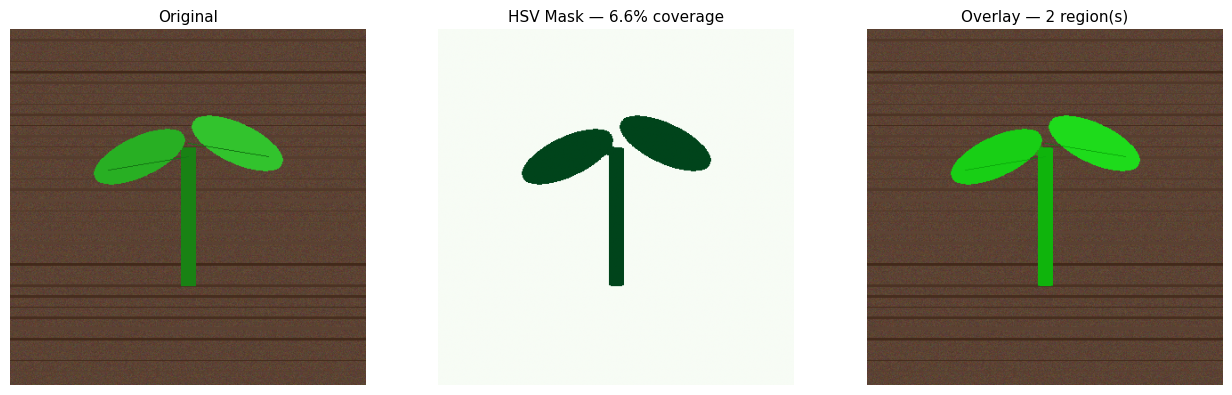

In [3]:
def overlay_mask(image_path, mask, color=(0, 255, 0), alpha=0.4):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    overlay = img.copy()
    overlay[mask > 0] = color
    return cv2.addWeighted(img, 1 - alpha, overlay, alpha, 0)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(cv2.cvtColor(cv2.imread(plant_path), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original', fontsize=11)

axes[1].imshow(result.mask, cmap='Greens')
axes[1].set_title(f'HSV Mask — {result.coverage_pct:.1f}% coverage', fontsize=11)

axes[2].imshow(overlay_mask(plant_path, result.mask))
axes[2].set_title(f'Overlay — {result.component_count} region(s)', fontsize=11)

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## All built-in colour profiles

In [ ]:
print('Available profiles:', seg.available_profiles)

profiles_to_show = ['green_plant', 'yellow_stress', 'brown_disease', 'dark_lesion']

fig, axes = plt.subplots(2, len(profiles_to_show), figsize=(14, 7))

for col, profile in enumerate(profiles_to_show):
    r = seg.segment(plant_path, profile=profile)
    axes[0, col].imshow(r.mask, cmap='hot')
    axes[0, col].set_title(f'{profile}\n{r.coverage_pct:.1f}%  |  {r.component_count} region(s)', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(overlay_mask(plant_path, r.mask, color=(255, 165, 0)))
    axes[1, col].axis('off')

plt.suptitle('Colour Profile Masks — Plant Image', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## segment_multi() — run multiple profiles in one call

In [ ]:
multi = seg.segment_multi(plant_path, profiles=['green_plant', 'yellow_stress', 'brown_disease'])

print('Multi-profile results:')
for profile, r in multi.items():
    print(f'  {profile:<16}: {r.coverage_pct:.2f}%  |  {r.component_count} region(s)')

## Custom HSV range

In [ ]:
# Define a custom orange range (e.g. for squash flowers or pepper fruit)
r_custom = seg.segment(
    plant_path,
    profile='custom',
    hsv_lower=(10, 80, 80),
    hsv_upper=(25, 255, 255),
)
print(f'Custom orange range — coverage: {r_custom.coverage_pct:.2f}%')

---
# Part 2 — SAM2Segmentor

SAM 2 generates precise pixel masks prompted by a **bounding box** or a **point click**.  
It does not classify — it only segments whatever you point it at.

**Typical workflow:** detector finds WHERE (Grounding DINO / OWL-ViT) → SAM draws exact shape.

> **Note:** SAM 2 downloads ~38 MB on first use. Requires `transformers` and `torch`.

In [2]:
from capabilities.segmentation.sam2_segmentor import SAM2Segmentor

sam = SAM2Segmentor()   # lazy-loaded on first call
print('SAM2Segmentor created (model loads on first call)')

SAM2Segmentor created (model loads on first call)


## segment_from_box() — use a bounding box as prompt

In [3]:
# Typical workflow: get box from a detector, then pass to SAM2
# Here we use a manually defined box for the demo
img = cv2.imread(plant_path)
h, w = img.shape[:2]

# Box covering the centre of the image
box = (w * 0.25, h * 0.20, w * 0.75, h * 0.85)

# Pass the flat box directly — do NOT wrap in lists
result_box = sam.segment_from_box(plant_path, box=box)

print(f'Has mask      : {result_box.has_mask}')
print(f'Area (pixels) : {result_box.area_px:.0f}')
print(f'Area (ratio)  : {result_box.area_ratio:.3f}  ({result_box.area_ratio*100:.1f}%)')
print(f'Prompt type   : {result_box.prompt_type}')
print(f'Inference time: {result_box.duration_ms:.0f} ms')

bbox = result_box.get_bounding_box()
print(f'Tight bbox    : {bbox}')

[SAM2Segmentor] Loading 'facebook/sam2-hiera-tiny' on cpu ...


You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

[SAM2Segmentor] Ready.
Has mask      : True
Area (pixels) : 90441
Area (ratio)  : 0.565  (56.5%)
Prompt type   : box
Inference time: 1478 ms
Tight bbox    : (0, 0, 2, 0)


## segment_from_point() — use a click point as prompt

In [4]:
# Click in the centre of the plant
point = (w // 2, h // 2)

result_point = sam.segment_from_point(plant_path, point=point)

print(f'Has mask      : {result_point.has_mask}')
print(f'Area (ratio)  : {result_point.area_ratio:.3f}')
print(f'Prompt type   : {result_point.prompt_type}')

Has mask      : True
Area (ratio)  : 0.121
Prompt type   : point


## Visualise SAM2 masks

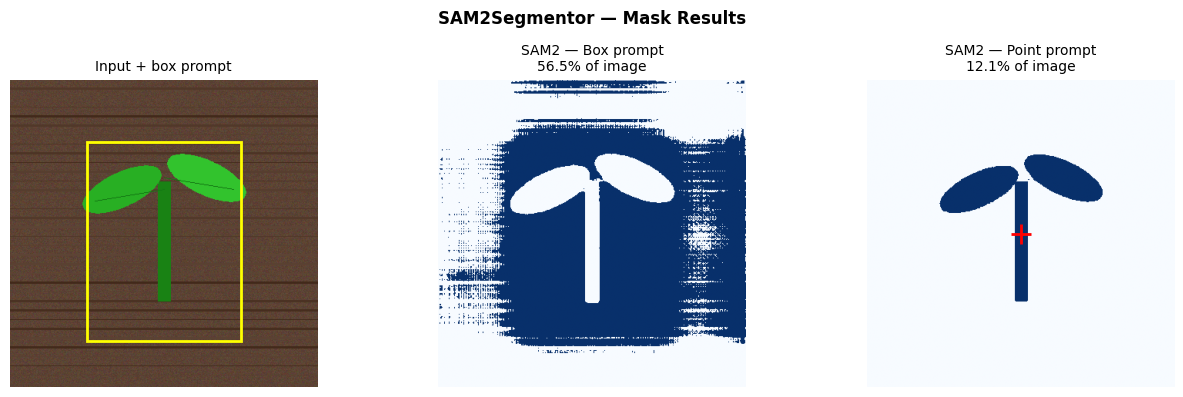

In [6]:
def prepare_mask(mask):
    m = np.array(mask)
    if m.ndim == 4:
        m = m[0]
    if m.ndim == 3:
        m = m[0]
    return m.astype(float)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
x1, y1, x2, y2 = [int(v) for v in box]
rect = plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor='yellow', linewidth=2)
axes[0].add_patch(rect)
axes[0].set_title('Input + box prompt', fontsize=10)

if result_box.has_mask:
    axes[1].imshow(prepare_mask(result_box.mask), cmap='Blues')
    axes[1].set_title(f'SAM2 — Box prompt\n{result_box.area_ratio*100:.1f}% of image', fontsize=10)
else:
    axes[1].text(0.5, 0.5, 'No mask\n(run with real model)', transform=axes[1].transAxes,
                ha='center', va='center', fontsize=11, color='gray')
    axes[1].set_title('SAM2 — Box prompt', fontsize=10)

if result_point.has_mask:
    axes[2].imshow(prepare_mask(result_point.mask), cmap='Blues')
    axes[2].plot(*point, 'r+', markersize=15, markeredgewidth=2)
    axes[2].set_title(f'SAM2 — Point prompt\n{result_point.area_ratio*100:.1f}% of image', fontsize=10)
else:
    axes[2].text(0.5, 0.5, 'No mask\n(run with real model)', transform=axes[2].transAxes,
                ha='center', va='center', fontsize=11, color='gray')
    axes[2].set_title('SAM2 — Point prompt', fontsize=10)

for ax in axes: ax.axis('off')
plt.suptitle('SAM2Segmentor — Mask Results', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Canonical workflow: Detector → SAM2

In [ ]:
# This is the standard pipeline for Use Case B (height estimation)
# Replace OWLViTDetector with GroundingDINODetector for better accuracy

print('Canonical pipeline:')
print()
print('  from capabilities.detection.owlvit_detector import OWLViTDetector')
print('  from capabilities.segmentation.sam2_segmentor import SAM2Segmentor')
print()
print('  detector = OWLViTDetector()')
print('  sam      = SAM2Segmentor()')
print()
print('  # Step 1: find the object')
print('  det_result = detector.detect(image_path, prompts=["a green seedling"])')
print()
print('  # Step 2: get the exact pixel mask')
print('  if det_result.found:')
print('      seg_result = sam.segment_from_box(image_path, box=det_result.best.bbox)')
print('      print(seg_result.mask.shape)   # (H, W) precise plant mask')
print('      print(seg_result.area_ratio)   # fraction of image = plant')